In [ ]:
%pip install qc-grader
%pip install mthree
%pip install qiskit-addon-opt-mapper
%pip install git+https://github.com/qiskit-community/qopt-best-practices.git
%pip install qiskit-aer
%pip install matplotlib
%pip install pandas
%pip install pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 775.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.6/412.6 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 94.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.2/224.2 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/76.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.7/120.7 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.5/54

In [ ]:
from qc_grader.challenges.qgss_2026 import (
    check_progress,
    grade_lab4b_ex1a,
    grade_lab4b_ex1b,
    grade_lab4b_ex2a,
    grade_lab4b_ex2b,
    grade_lab4b_ex2c,
    grade_lab4b_ex2d,
    grade_lab4b_ex2,
    grade_lab4b_ex3a,
    grade_lab4b_ex3b,
    grade_lab4b_ex3c,
    grade_lab4b_ex4a,
    grade_lab4b_ex4b,
    grade_lab4b_ex4c,
    grade_lab4b_ex4d,
    grade_lab4b_ex4,
    grade_lab4b_exbonus,
)

# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from qiskit.quantum_info import SparsePauliOp

from scipy.optimize import minimize
import networkx as nx
from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    Session,
    EstimatorV2 as Estimator,
    SamplerV2 as Sampler,
)
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime.options import SamplerOptions, EstimatorOptions
import mthree

from qiskit_addon_opt_mapper.applications import Maxcut
from qiskit_addon_opt_mapper.translators import to_ising
from qopt_best_practices.circuit_library import annotated_qaoa_ansatz
from qopt_best_practices.transpilation import UnrollBoxes

from qiskit.transpiler import CouplingMap
from qopt_best_practices.transpilation.generate_preset_qaoa_pass_manager import (
    generate_preset_qaoa_pass_manager,
)
from qiskit.transpiler.passes.routing.commuting_2q_gate_routing import SwapStrategy
from itertools import combinations

# Import utils

from random import sample

# Set seed for reproducibility
seed = 42

In [ ]:
from pathlib import Path
from urllib.request import urlretrieve

Path("utils").mkdir(exist_ok=True)

functions_url = (
    "https://raw.githubusercontent.com/"
    "qiskit-community/qgss-2026/main/lab-4/utils/functions.py"
)

urlretrieve(functions_url, "utils/functions.py")

print("Downloaded successfully:")
print(Path("utils/functions.py").resolve())
print("File exists:", Path("utils/functions.py").exists())

Downloaded successfully:
/content/utils/functions.py
File exists: True


In [ ]:
from utils.functions import (
    plot_partition_graph,
    analyze_partition_result,
    analyze_error_mitigation_result,
    compare_error_mitigation_methods,
    plot_error_mitigation_comparison,
    print_comparison_summary,
    get_partitions,
    calc_cut_size,
)

print("Lab 4 utilities imported successfully.")

Lab 4 utilities imported successfully.


In [ ]:
 #Paste your IBM Cloud credentials here. You only need to do this once per environment.
# After it works, you can comment these lines out so the credentials do not stay in the file.

token = "Your_token"
instance = "Your_instance"
# looks like "crn:v1:bluemix:public:quantum-computing:..."

QiskitRuntimeService.save_account(
    token=token,
    instance=instance,
    overwrite=True,
    set_as_default=True,)
check_progress()

Fetching your progress. Please wait...

📊 Your progress

Exercises passed: 25/49
Total score: 29.0

Lab "lab0" — 4/4 passed, score 4.0
  ✅ ex1 — score 1.0
  ✅ ex2 — score 1.0
  ✅ ex3 — score 1.0
  ✅ ex4 — score 1.0

Lab "lab1" — 7/7 passed, score 10.0
  ✅ ex1 — score 1.0
  ✅ ex2 — score 2.0
  ✅ ex3 — score 1.0
  ✅ ex4 — score 1.0
  ✅ ex5 — score 1.0
  ✅ ex6 — score 2.0
  ✅ ex7 — score 2.0

Lab "lab2" — 7/7 passed, score 8.0
  ✅ ex1 — score 2.0
  ✅ ex2 — score 1.0
  ✅ ex3 — score 1.0
  ✅ ex4 — score 1.0
  ✅ ex5 — score 1.0
  ✅ ex6 — score 1.0
  ✅ ex7 — score 1.0

Lab "lab3" — 5/5 passed, score 5.0
  ✅ ex1 — score 1.0
  ✅ ex2 — score 1.0
  ✅ ex3 — score 1.0
  ✅ ex4 — score 1.0
  ✅ ex5 — score 1.0

Lab "lab4a" — 2/2 passed, score 2.0
  ✅ ex1 — score 1.0
  ✅ ex2 — score 1.0

Lab "lab4b" — 0/16 passed, score 0.0
  ⬜ ex1a — score 0.0
  ⬜ ex1b — score 0.0
  ⬜ ex2a — score 0.0
  ⬜ ex2b — score 0.0
  ⬜ ex2c — score 0.0
  ⬜ ex2d — score 0.0
  ⬜ ex2 — score 0.0
  ⬜ ex3a — score 0.0
  ⬜ ex3b — sco

In [ ]:
service = QiskitRuntimeService()
backend = service.least_busy(simulator=False, operational=True, min_num_qubits=156)
print(f"We are using {backend.name}")

We are using ibm_marrakesh


In [ ]:
service = QiskitRuntimeService()

backend = service.least_busy(
    simulator=False,
    operational=True,
    min_num_qubits=156,
)

print(f"We are using {backend.name}")

We are using ibm_marrakesh


In [ ]:
 from qiskit_aer import AerSimulator
 backend = AerSimulator.from_backend(backend)

In [ ]:
from qiskit_aer import AerSimulator

backend = AerSimulator.from_backend(backend)

print("Using simulator:", backend.name)

Using simulator: aer_simulator_from(aer_simulator_from(ibm_marrakesh))


In [ ]:
print(type(backend))
print(backend.name)

<class 'qiskit_aer.backends.aer_simulator.AerSimulator'>
aer_simulator_from(aer_simulator_from(ibm_marrakesh))


In [ ]:
# Define our partition problem
numbers = [3, 5, 7, 9, 11, 13]

n = len(numbers)

print(f"Numbers to partition: {numbers}")
print(f"Total sum: {sum(numbers)}")
print(f"Target sum per partition: {sum(numbers) / 2}")

Numbers to partition: [3, 5, 7, 9, 11, 13]
Total sum: 48
Target sum per partition: 24.0


In [ ]:
def build_partition_graph(numbers: list[int]) -> nx.Graph:
    """
    Create a complete weighted graph where edge weights are the product
    of the corresponding values in `numbers`.
    """
    n = len(numbers)
    nodes = range(n)

    # Create a complete graph containing nodes 0 through n-1.
    partition_graph = nx.complete_graph(nodes)

    # Assign weight numbers[i] * numbers[j] to every edge.
    for i, j in partition_graph.edges():
        partition_graph[i][j]["weight"] = numbers[i] * numbers[j]

    return partition_graph


partition_graph = build_partition_graph(numbers)

In [ ]:
print("Nodes:", partition_graph.nodes())
print("Number of nodes:", partition_graph.number_of_nodes())
print("Number of edges:", partition_graph.number_of_edges())

for i, j, data in partition_graph.edges(data=True):
    print(
        f"Edge ({i}, {j}): "
        f"{numbers[i]} × {numbers[j]} = {data['weight']}"
    )

Nodes: [0, 1, 2, 3, 4, 5]
Number of nodes: 6
Number of edges: 15
Edge (0, 1): 3 × 5 = 15
Edge (0, 2): 3 × 7 = 21
Edge (0, 3): 3 × 9 = 27
Edge (0, 4): 3 × 11 = 33
Edge (0, 5): 3 × 13 = 39
Edge (1, 2): 5 × 7 = 35
Edge (1, 3): 5 × 9 = 45
Edge (1, 4): 5 × 11 = 55
Edge (1, 5): 5 × 13 = 65
Edge (2, 3): 7 × 9 = 63
Edge (2, 4): 7 × 11 = 77
Edge (2, 5): 7 × 13 = 91
Edge (3, 4): 9 × 11 = 99
Edge (3, 5): 9 × 13 = 117
Edge (4, 5): 11 × 13 = 143


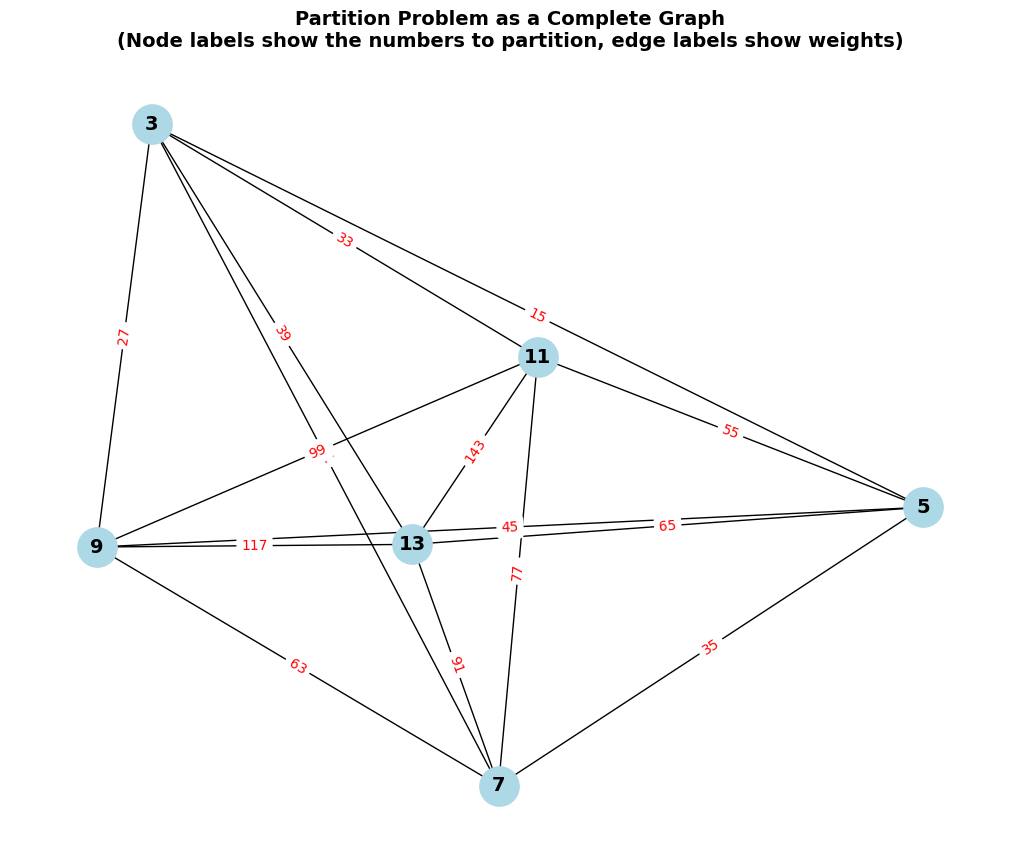


Each node represents a number from our set.
Edges connect all pairs, weighted by the product of the numbers.


In [ ]:
plot_partition_graph(
    partition_graph,
    numbers,
    seed=seed,
    show=True,
)

In [ ]:
grade_lab4b_ex1a(partition_graph)

Grading your answer. Please wait...

Congratulations! 🎉 Your partition graph is correct. The graph has 6 nodes and 15 edges, and each edge weight correctly represents the product of the two numbers it connects. 
You scored 1 on this exercise.


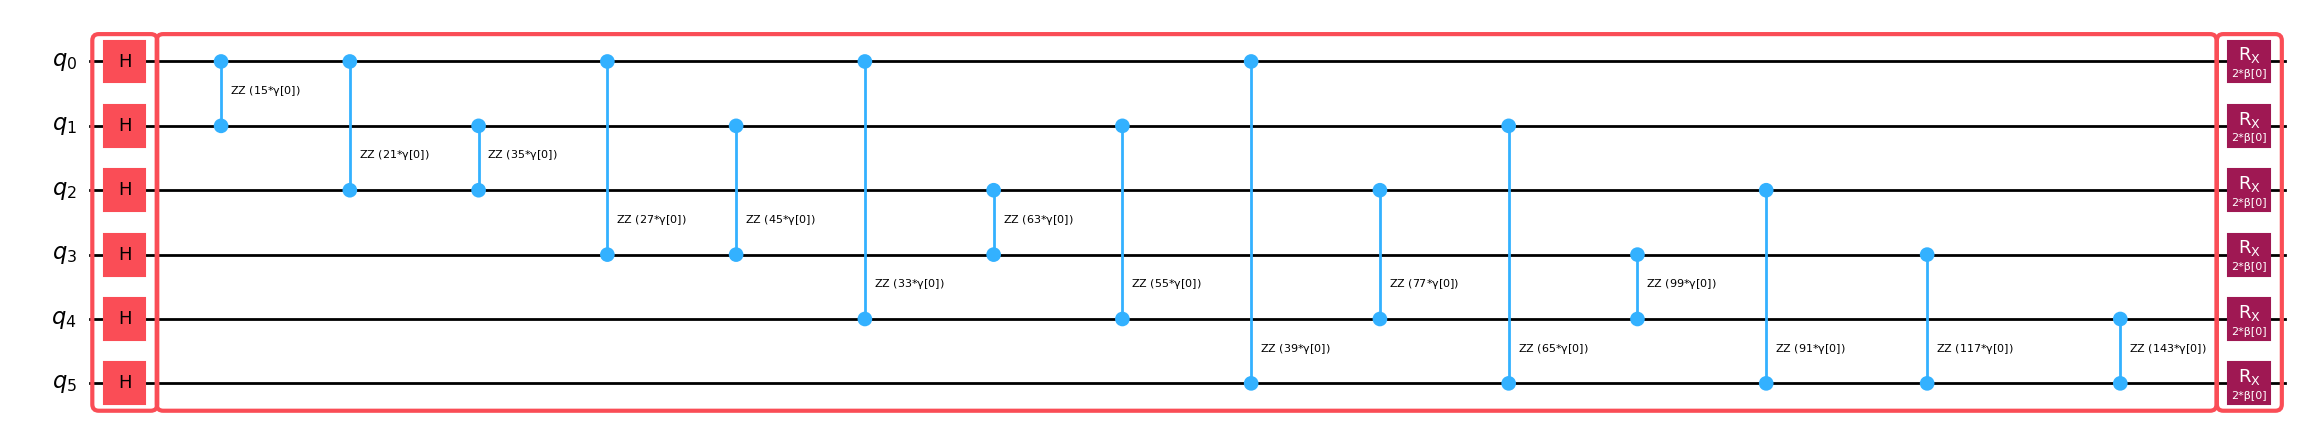

In [ ]:
layers = 1

# ---- TODO : Task 1b ---

# Create the MaxCut application from the weighted graph.
maxcut = Maxcut(partition_graph)

# Convert MaxCut to the OptimizationProblem format expected by to_ising().
optimization_problem = maxcut.to_optimization_problem()

# Convert the optimization problem to an Ising Hamiltonian.
partition_hamiltonian, partition_offset = to_ising(
    optimization_problem
)

# Construct the annotated QAOA circuit.
circuit = annotated_qaoa_ansatz(
    partition_hamiltonian,
    reps=layers,
)

# ---- end of TODO : Task 1b ---

# Make a measured copy for the Sampler.
circuit_sampler = circuit.copy()
circuit_sampler.measure_all()

display(
    circuit.draw(
        idle_wires=False,
        fold=-1,
        output="mpl",
    )
)

In [ ]:
print("Hamiltonian type:", type(partition_hamiltonian))
print("Hamiltonian:", partition_hamiltonian)
print("Offset:", partition_offset)
print("Circuit qubits:", circuit.num_qubits)
print("Circuit parameters:", circuit.parameters)
print("Measured circuit bits:", circuit_sampler.num_clbits)

Hamiltonian type: <class 'qiskit.quantum_info.operators.symplectic.sparse_pauli_op.SparsePauliOp'>
Hamiltonian: SparsePauliOp(['IIIIZZ', 'IIIZIZ', 'IIZIIZ', 'IZIIIZ', 'ZIIIIZ', 'IIIZZI', 'IIZIZI', 'IZIIZI', 'ZIIIZI', 'IIZZII', 'IZIZII', 'ZIIZII', 'IZZIII', 'ZIZIII', 'ZZIIII'],
              coeffs=[ 7.5+0.j, 10.5+0.j, 13.5+0.j, 16.5+0.j, 19.5+0.j, 17.5+0.j, 22.5+0.j,
 27.5+0.j, 32.5+0.j, 31.5+0.j, 38.5+0.j, 45.5+0.j, 49.5+0.j, 58.5+0.j,
 71.5+0.j])
Offset: -462.5
Circuit qubits: 6
Circuit parameters: ParameterView([ParameterVectorElement(β[0]), ParameterVectorElement(γ[0])])
Measured circuit bits: 6


In [ ]:
grade_lab4b_ex1b(
    partition_hamiltonian,
    circuit,
)

Grading your answer. Please wait...

Congratulations! 🎉 Your Hamiltonian and circuit are correct.
You scored 1 on this exercise.


In [ ]:
grade_lab4b_ex1b(partition_hamiltonian, circuit)

Grading your answer. Please wait...

Congratulations! 🎉 Your Hamiltonian and circuit are correct.
You scored 1 on this exercise.


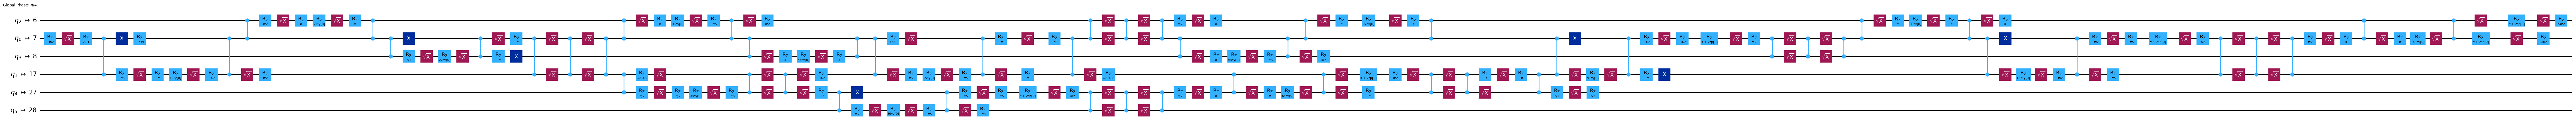

In [ ]:
# Create pass manager for transpilation
pm = generate_preset_pass_manager(
    optimization_level=3, backend=backend, seed_transpiler=seed
)
edge_coloring = nx.greedy_color(
    nx.line_graph(partition_graph), strategy="saturation_largest_first"
)
edge_coloring.update({(k[1], k[0]): v for k, v in edge_coloring.items()})

num_colors = len(set(edge_coloring.values()))


# Make an empty swap strategy as we have a hardware-native graph here
cmap = CouplingMap(partition_graph.edges())
cmap.make_symmetric()

swap_strategy = SwapStrategy(cmap, ())  # no SWAPs needed

staged_pm = generate_preset_qaoa_pass_manager(
    backend, swap_strategy, initial_layout=None, edge_coloring=edge_coloring
)
# pm = staged_pm
candidate_circuit = pm.run(UnrollBoxes()(circuit))
candidate_circuit_sampler = pm.run(UnrollBoxes()(circuit_sampler))
candidate_circuit.draw("mpl", fold=False, idle_wires=False)

In [ ]:
from pathlib import Path
from urllib.request import urlretrieve

Path("utils").mkdir(exist_ok=True)

base_url = (
    "https://raw.githubusercontent.com/"
    "qiskit-community/qgss-2026/main/lab-4/utils/"
)

required_files = [
    "pretrained_parameters_small.npy",
    "pretrained_parameters_pce.npy",
    "numbers_large.npy",
    "numbers_bonus.npy",
]

for filename in required_files:
    destination = Path("utils") / filename

    urlretrieve(
        base_url + filename,
        destination,
    )

    print(
        filename,
        "downloaded:",
        destination.exists(),
        "size:",
        destination.stat().st_size,
        "bytes",
    )

pretrained_parameters_small.npy downloaded: True size: 144 bytes
pretrained_parameters_pce.npy downloaded: True size: 160 bytes
numbers_large.npy downloaded: True size: 1408 bytes
numbers_bonus.npy downloaded: True size: 12928 bytes


In [ ]:
from pathlib import Path

for path in sorted(Path("utils").iterdir()):
    print(path)

utils/__pycache__
utils/functions.py
utils/numbers_bonus.npy
utils/numbers_large.npy
utils/pretrained_parameters_pce.npy
utils/pretrained_parameters_small.npy


In [ ]:
training = False
init_params = np.load(
    "utils/pretrained_parameters_small.npy"
)

print("Initial parameters:", init_params)
print("Shape:", init_params.shape)

Initial parameters: [ 0.16599657 -0.00509131]
Shape: (2,)


In [ ]:
objective_func_vals = []  # Global variable


def cost_func_estimator(params, ansatz, hamiltonian, estimator):

    # transform the observable defined on virtual qubits to
    # an observable defined on all physical qubits
    isa_hamiltonian = hamiltonian.apply_layout(ansatz.layout)

    pub = (ansatz, isa_hamiltonian, params)
    job = estimator.run([pub])

    results = job.result()[0]
    cost = results.data.evs

    objective_func_vals.append(cost)

    return cost


max_iter = 30

if training:
    # Try with Session session, fallback to Job mode if it fails
    try:
        session = Session(backend=backend)
        estimator = Estimator(mode=session)
        use_session = True
        print("We are using Session mode")
    except:
        estimator = Estimator(mode=backend)
        use_session = False
        print("We are using Job mode")

    estimator.options.default_shots = 10000
    estimator.options.environment.job_tags = ["qgss26"]

    if use_session:
        with session:
            result = minimize(
                cost_func_estimator,
                init_params,
                args=(candidate_circuit, partition_hamiltonian, estimator),
                method="COBYLA",
                options={"maxiter": max_iter, "tol": 1e-8, "rhobeg": 0.001},
            )
    else:
        result = minimize(
            cost_func_estimator,
            init_params,
            args=(candidate_circuit, partition_hamiltonian, estimator),
            method="COBYLA",
            options={"maxiter": max_iter, "tol": 1e-8, "rhobeg": 0.001},
        )

    optimized_params = result.x
    np.save("optimized_parameters_small_custom.npy", optimized_params)
    plt.figure(figsize=(12, 6))
    plt.plot(objective_func_vals, lw=0.75, marker=".")
    plt.xlabel("Iteration")
    plt.ylabel("Cost")
    plt.show()


else:
    optimized_params = np.load("utils/pretrained_parameters_small.npy")
optimized_circuit = candidate_circuit_sampler.assign_parameters(optimized_params)

In [ ]:
training = False

init_params = np.load(
    "utils/pretrained_parameters_small.npy"
)

In [ ]:
objective_func_vals = []


def cost_func_estimator(params, ansatz, hamiltonian, estimator):
    isa_hamiltonian = hamiltonian.apply_layout(ansatz.layout)

    pub = (ansatz, isa_hamiltonian, params)
    job = estimator.run([pub])

    results = job.result()[0]
    cost = results.data.evs

    objective_func_vals.append(cost)

    return cost


max_iter = 30

if training:
    try:
        session = Session(backend=backend)
        estimator = Estimator(mode=session)
        use_session = True
        print("We are using Session mode")
    except Exception:
        estimator = Estimator(mode=backend)
        use_session = False
        print("We are using Job mode")

    estimator.options.default_shots = 10000
    estimator.options.environment.job_tags = ["qgss26"]

    if use_session:
        with session:
            result = minimize(
                cost_func_estimator,
                init_params,
                args=(
                    candidate_circuit,
                    partition_hamiltonian,
                    estimator,
                ),
                method="COBYLA",
                options={
                    "maxiter": max_iter,
                    "tol": 1e-8,
                    "rhobeg": 0.001,
                },
            )
    else:
        result = minimize(
            cost_func_estimator,
            init_params,
            args=(
                candidate_circuit,
                partition_hamiltonian,
                estimator,
            ),
            method="COBYLA",
            options={
                "maxiter": max_iter,
                "tol": 1e-8,
                "rhobeg": 0.001,
            },
        )

    optimized_params = result.x

else:
    optimized_params = np.load(
        "utils/pretrained_parameters_small.npy"
    )


optimized_circuit = (
    candidate_circuit_sampler.assign_parameters(
        optimized_params
    )
)

print("Training enabled:", training)
print("Parameters:", optimized_params)
print("Free parameters remaining:", optimized_circuit.num_parameters)

Training enabled: False
Parameters: [ 0.16599657 -0.00509131]
Free parameters remaining: 0


In [ ]:
print("=" * 80)
print("VERSION 1: No Error Mitigation or Suppression")
print("=" * 80)

options_v1 = SamplerOptions()

# ---- TODO : Task 2a ----
shots = 1000
options_v1.default_shots = shots
# ---- end of TODO : Task 2a ----

print(options_v1)

VERSION 1: No Error Mitigation or Suppression
SamplerOptions(_VERSION=2, max_execution_time=Unset, environment=EnvironmentOptions(log_level='WARNING', job_tags=None, private=False), simulator=SimulatorOptions(noise_model=Unset, seed_simulator=Unset, coupling_map=Unset, basis_gates=Unset), default_shots=1000, dynamical_decoupling=DynamicalDecouplingOptions(enable=Unset, sequence_type=Unset, extra_slack_distribution=Unset, scheduling_method=Unset, skip_reset_qubits=Unset), execution=SamplerExecutionOptionsV2(init_qubits=Unset, rep_delay=Unset, meas_type=Unset), twirling=TwirlingOptions(enable_gates=Unset, enable_measure=Unset, num_randomizations=Unset, shots_per_randomization=Unset, strategy=Unset), experimental=Unset)


In [ ]:
grade_lab4b_ex2a(options_v1)

Grading your answer. Please wait...

Congratulations! 🎉  Your error mitigation analysis on the Sampler looks correct.
You scored 1 on this exercise.


In [ ]:
print("=" * 80)
print("VERSION 2: Error Suppression Only")
print("=" * 80)

options_v2 = SamplerOptions()

# ---- TODO : Task 2b ----
options_v2.default_shots = shots

options_v2.dynamical_decoupling.enable = True
options_v2.dynamical_decoupling.sequence_type = "XY4"

options_v2.twirling.enable_gates = True
options_v2.twirling.enable_measure = True
options_v2.twirling.num_randomizations = 32
# ---- end of TODO : Task 2b ----

print(options_v2)

VERSION 2: Error Suppression Only
SamplerOptions(_VERSION=2, max_execution_time=Unset, environment=EnvironmentOptions(log_level='WARNING', job_tags=None, private=False), simulator=SimulatorOptions(noise_model=Unset, seed_simulator=Unset, coupling_map=Unset, basis_gates=Unset), default_shots=1000, dynamical_decoupling=DynamicalDecouplingOptions(enable=True, sequence_type='XY4', extra_slack_distribution=Unset, scheduling_method=Unset, skip_reset_qubits=Unset), execution=SamplerExecutionOptionsV2(init_qubits=Unset, rep_delay=Unset, meas_type=Unset), twirling=TwirlingOptions(enable_gates=True, enable_measure=True, num_randomizations=32, shots_per_randomization=Unset, strategy=Unset), experimental=Unset)


In [ ]:
grade_lab4b_ex2b(options_v2)

Grading your answer. Please wait...

Congratulations! 🎉  Your error mitigation analysis on the Sampler looks correct.
You scored 1 on this exercise.


In [ ]:
from qiskit_aer import AerSimulator

print("Backend type:", type(backend))
print("Backend name:", backend.name)

assert isinstance(backend, AerSimulator)

Backend type: <class 'qiskit_aer.backends.aer_simulator.AerSimulator'>
Backend name: aer_simulator_from(aer_simulator_from(ibm_marrakesh))


In [ ]:
sampler_v1 = Sampler(
    mode=backend,
    options=options_v1,
)

pub_v1 = (optimized_circuit,)
job_v1 = sampler_v1.run([pub_v1], shots=shots)

print("Local job ID:", job_v1.job_id())

result_v1 = job_v1.result()[0]
counts_bin_v1 = result_v1.data.meas.get_counts()

final_distribution_bin_v1 = {
    key: value / shots
    for key, value in counts_bin_v1.items()
}

final_distribution_bin_v1 = dict(
    sorted(
        final_distribution_bin_v1.items(),
        key=lambda item: item[1],
        reverse=True,
    )
)

print("Results — no mitigation:")
print(final_distribution_bin_v1)

Local job ID: 29ce8a6f-b72f-414b-8f06-8d70cc80b8e7
Results — no mitigation:
{'011001': 0.035, '101001': 0.034, '001101': 0.032, '101000': 0.029, '010101': 0.028, '100011': 0.028, '011010': 0.027, '100100': 0.026, '101010': 0.026, '110000': 0.025, '110010': 0.025, '010011': 0.025, '011100': 0.024, '001110': 0.023, '110001': 0.022, '010100': 0.021, '011000': 0.021, '001001': 0.021, '001111': 0.02, '100110': 0.02, '100101': 0.02, '110011': 0.02, '011011': 0.02, '101100': 0.019, '000111': 0.019, '100111': 0.018, '010111': 0.018, '010110': 0.018, '101011': 0.018, '011101': 0.018, '100010': 0.017, '001011': 0.016, '011110': 0.015, '110100': 0.015, '000110': 0.014, '001010': 0.013, '100001': 0.013, '101101': 0.013, '001100': 0.013, '101110': 0.012, '010001': 0.011, '100000': 0.01, '101111': 0.01, '010010': 0.009, '111001': 0.009, '111100': 0.008, '000011': 0.008, '111000': 0.008, '010000': 0.007, '001000': 0.007, '000101': 0.007, '110101': 0.007, '111101': 0.007, '110111': 0.006, '111010': 0.

In [ ]:
# AerSimulator jobs are local and cannot be retrieved through service.job().
print("Using existing local simulator job:", job_v1.job_id())
print("The version 1 results are already available.")

Using existing local simulator job: 29ce8a6f-b72f-414b-8f06-8d70cc80b8e7
The version 1 results are already available.


In [ ]:
sampler_v2 = Sampler(
    mode=backend,
    options=options_v2,
)

pub_v2 = (optimized_circuit,)
job_v2 = sampler_v2.run(
    [pub_v2],
    shots=shots,
)

print("Local job ID:", job_v2.job_id())

result_v2 = job_v2.result()[0]
counts_bin_v2 = result_v2.data.meas.get_counts()

final_distribution_bin_v2 = {
    key: value / shots
    for key, value in counts_bin_v2.items()
}

final_distribution_bin_v2 = dict(
    sorted(
        final_distribution_bin_v2.items(),
        key=lambda item: item[1],
        reverse=True,
    )
)

print("Results — suppression only:")
print(final_distribution_bin_v2)

Local job ID: fd99acaf-3357-4f57-888c-20146bf24ce2
Results — suppression only:
{'001111': 0.03, '001110': 0.029, '101001': 0.028, '100110': 0.028, '101010': 0.028, '011001': 0.027, '101000': 0.027, '100011': 0.027, '101100': 0.026, '011000': 0.026, '001010': 0.025, '010111': 0.025, '011010': 0.024, '010110': 0.023, '011100': 0.023, '010100': 0.022, '010101': 0.022, '001011': 0.022, '001101': 0.022, '110010': 0.021, '100111': 0.021, '110001': 0.021, '011011': 0.021, '001100': 0.02, '100101': 0.02, '100010': 0.018, '110011': 0.018, '010011': 0.018, '101011': 0.017, '110000': 0.017, '100001': 0.016, '110101': 0.016, '011101': 0.015, '110100': 0.015, '010001': 0.015, '101101': 0.014, '111000': 0.013, '110110': 0.013, '000111': 0.013, '010010': 0.012, '111001': 0.012, '100100': 0.011, '101110': 0.011, '000101': 0.01, '010000': 0.01, '111010': 0.009, '100000': 0.008, '101111': 0.008, '001001': 0.008, '000010': 0.007, '000110': 0.007, '111011': 0.007, '000001': 0.007, '011110': 0.006, '001000

In [ ]:
print("=" * 80)
print("VERSION 3: M3 Error Mitigation Only")
print("=" * 80)

options_v3 = options_v1
counts_bin_v3 = counts_bin_v1
job_v3 = job_v1

# ---- TODO : Task 2c ----

meas_map_v3 = (
    mthree.utils.final_measurement_mapping(
        optimized_circuit
    )
)

mit_v3 = mthree.M3Mitigation(backend)

mit_v3.cals_from_system(
    meas_map_v3
)

m3_quasis_v3 = mit_v3.apply_correction(
    counts_bin_v3,
    meas_map_v3,
)

# ---- end of TODO : Task 2c ----

print("Measurement map:", meas_map_v3)
print("M3 quasi-probabilities:")
print(dict(m3_quasis_v3))

VERSION 3: M3 Error Mitigation Only
Measurement map: {0: 8, 1: 9, 2: 18, 3: 10, 4: 12, 5: 11}
M3 quasi-probabilities:
{'000000': np.float32(0.0027516023), '000001': np.float32(0.0035972926), '000010': np.float32(0.0056576487), '000011': np.float32(0.007395406), '000100': np.float32(0.003201572), '000101': np.float32(0.0063066483), '000110': np.float32(0.013891986), '000111': np.float32(0.01925922), '001000': np.float32(0.006244872), '001001': np.float32(0.020822136), '001010': np.float32(0.012648345), '001011': np.float32(0.015906703), '001100': np.float32(0.012632265), '001101': np.float32(0.032998905), '001110': np.float32(0.023493243), '001111': np.float32(0.02012537), '010000': np.float32(0.0063870014), '010001': np.float32(0.010383337), '010010': np.float32(0.008400513), '010011': np.float32(0.025589108), '010100': np.float32(0.02128034), '010101': np.float32(0.02899418), '010110': np.float32(0.01832971), '010111': np.float32(0.018220294), '011000': np.float32(0.02129771), '011001

In [ ]:
grade_lab4b_ex2c(options_v3, optimized_circuit, meas_map_v3, m3_quasis_v3, counts_bin_v3)

Grading your answer. Please wait...

Congratulations! 🎉  Your error mitigation analysis on the Sampler looks correct.
You scored 1 on this exercise.


In [ ]:
def convert_bin_list(dist, shots=10000):
    counts = {
        key: (
            int(round(float(value) * shots))
            if float(value) >= 0
            else 0
        )
        for key, value in dist.items()
    }

    total_counts = sum(counts.values())

    return {
        key: round(
            value / total_counts,
            int(np.log10(shots)),
        )
        for key, value in counts.items()
    }


final_distribution_bin_v3 = convert_bin_list(
    dict(m3_quasis_v3),
    shots=shots,
)

final_distribution_bin_v3 = dict(
    sorted(
        final_distribution_bin_v3.items(),
        key=lambda item: item[1],
        reverse=True,
    )
)

print("Results — M3 only:")
print(final_distribution_bin_v3)

Results — M3 only:
{'011001': 0.036, '101001': 0.035, '001101': 0.033, '101000': 0.03, '010101': 0.029, '100011': 0.029, '011010': 0.028, '100100': 0.027, '010011': 0.026, '101010': 0.026, '110000': 0.026, '110010': 0.026, '011100': 0.025, '001110': 0.023, '110001': 0.023, '001001': 0.021, '010100': 0.021, '011000': 0.021, '001111': 0.02, '011011': 0.02, '100101': 0.02, '100110': 0.02, '110011': 0.02, '000111': 0.019, '101100': 0.019, '010110': 0.018, '010111': 0.018, '011101': 0.018, '100111': 0.018, '101011': 0.018, '100010': 0.017, '001011': 0.016, '011110': 0.015, '110100': 0.015, '000110': 0.014, '001010': 0.013, '001100': 0.013, '100001': 0.013, '101101': 0.012, '101110': 0.012, '010001': 0.01, '100000': 0.01, '101111': 0.01, '010010': 0.008, '111000': 0.008, '111001': 0.008, '111100': 0.008, '000011': 0.007, '111101': 0.007, '000010': 0.006, '000101': 0.006, '001000': 0.006, '010000': 0.006, '110101': 0.006, '110111': 0.006, '011111': 0.005, '110110': 0.005, '111010': 0.005, '00

In [ ]:
grade_lab4b_ex2c(
    options_v3,
    optimized_circuit,
    meas_map_v3,
    m3_quasis_v3,
    counts_bin_v3,
)

Grading your answer. Please wait...

Congratulations! 🎉  Your error mitigation analysis on the Sampler looks correct.
You scored 1 on this exercise.


In [ ]:
print("=" * 80)
print("VERSION 4: M3 + Error Suppression")
print("=" * 80)

options_v4 = options_v2
counts_bin_v4 = counts_bin_v2
job_v4 = job_v2

# ---- TODO : Task 2d ----

meas_map_v4 = (
    mthree.utils.final_measurement_mapping(
        optimized_circuit
    )
)

mit_v4 = mthree.M3Mitigation(backend)

mit_v4.cals_from_system(
    meas_map_v4
)

m3_quasis_v4 = mit_v4.apply_correction(
    counts_bin_v4,
    meas_map_v4,
)

# ---- end of TODO : Task 2d ----

final_distribution_bin_v4 = convert_bin_list(
    dict(m3_quasis_v4),
    shots=shots,
)

final_distribution_bin_v4 = dict(
    sorted(
        final_distribution_bin_v4.items(),
        key=lambda item: item[1],
        reverse=True,
    )
)

print("Results — M3 plus suppression:")
print(final_distribution_bin_v4)

VERSION 4: M3 + Error Suppression
Results — M3 plus suppression:
{'001111': 0.031, '001110': 0.03, '100110': 0.029, '101001': 0.029, '011001': 0.028, '100011': 0.028, '101000': 0.028, '101010': 0.028, '101100': 0.027, '010111': 0.026, '011000': 0.026, '001010': 0.025, '011010': 0.024, '011100': 0.024, '010110': 0.023, '001011': 0.022, '001101': 0.022, '010100': 0.022, '010101': 0.022, '011011': 0.021, '100111': 0.021, '110001': 0.021, '110010': 0.021, '001100': 0.02, '100101': 0.02, '010011': 0.018, '100010': 0.018, '110011': 0.018, '101011': 0.017, '110000': 0.017, '100001': 0.016, '110101': 0.016, '010001': 0.015, '011101': 0.015, '110100': 0.015, '101101': 0.014, '000111': 0.013, '110110': 0.013, '111000': 0.013, '010010': 0.012, '111001': 0.012, '100100': 0.011, '000101': 0.01, '010000': 0.01, '101110': 0.01, '100000': 0.008, '111010': 0.008, '000001': 0.007, '000010': 0.007, '001001': 0.007, '101111': 0.007, '111011': 0.007, '000110': 0.006, '000000': 0.005, '001000': 0.005, '0111

In [ ]:
grade_lab4b_ex2d(
    options_v4,
    optimized_circuit,
    meas_map_v4,
    m3_quasis_v4,
    counts_bin_v4,
)

Grading your answer. Please wait...

Congratulations! 🎉  Your error mitigation analysis on the Sampler looks correct.
You scored 1 on this exercise.


In [ ]:
print("=" * 80)
print("SUMMARY")
print("=" * 80)

print(
    "V1 — no mitigation:",
    list(final_distribution_bin_v1.items())[:3],
)

print(
    "V2 — suppression:",
    list(final_distribution_bin_v2.items())[:3],
)

print(
    "V3 — M3:",
    list(final_distribution_bin_v3.items())[:3],
)

print(
    "V4 — M3 + suppression:",
    list(final_distribution_bin_v4.items())[:3],
)

SUMMARY
V1 — no mitigation: [('011001', 0.035), ('101001', 0.034), ('001101', 0.032)]
V2 — suppression: [('001111', 0.03), ('001110', 0.029), ('101001', 0.028)]
V3 — M3: [('011001', 0.036), ('101001', 0.035), ('001101', 0.033)]
V4 — M3 + suppression: [('001111', 0.031), ('001110', 0.03), ('100110', 0.029)]


In [ ]:
bitstring_v1, set1_v1, set2_v1, difference_v1, v1 = (
    analyze_partition_result(
        final_distribution_bin_v1,
        numbers,
        partition_graph,
        "VERSION 1: No Mitigation",
    )
)

bitstring_v2, set1_v2, set2_v2, difference_v2, v2 = (
    analyze_partition_result(
        final_distribution_bin_v2,
        numbers,
        partition_graph,
        "VERSION 2: Error Suppression Only",
    )
)

bitstring_v3, set1_v3, set2_v3, difference_v3, v3 = (
    analyze_partition_result(
        final_distribution_bin_v3,
        numbers,
        partition_graph,
        "VERSION 3: M3 Only",
    )
)

bitstring_v4, set1_v4, set2_v4, difference_v4, v4 = (
    analyze_partition_result(
        final_distribution_bin_v4,
        numbers,
        partition_graph,
        "VERSION 4: M3 + Suppression",
    )
)


Analysis for VERSION 1: No Mitigation
Result bitstring: [1, 0, 0, 1, 1, 0]

QAOA Partition Result:
Set 1: [3, 9, 11] (sum = 23)
Set 2: [5, 7, 13] (sum = 25)
Difference: 2

Analysis for VERSION 2: Error Suppression Only
Result bitstring: [1, 1, 1, 1, 0, 0]

QAOA Partition Result:
Set 1: [3, 5, 7, 9] (sum = 24)
Set 2: [11, 13] (sum = 24)
Difference: 0

Analysis for VERSION 3: M3 Only
Result bitstring: [1, 0, 0, 1, 1, 0]

QAOA Partition Result:
Set 1: [3, 9, 11] (sum = 23)
Set 2: [5, 7, 13] (sum = 25)
Difference: 2

Analysis for VERSION 4: M3 + Suppression
Result bitstring: [1, 1, 1, 1, 0, 0]

QAOA Partition Result:
Set 1: [3, 5, 7, 9] (sum = 24)
Set 2: [11, 13] (sum = 24)
Difference: 0


In [ ]:
options_list = [
    options_v1,
    options_v2,
    options_v3,
    options_v4,
]

probs_list = [
    final_distribution_bin_v1,
    final_distribution_bin_v2,
    final_distribution_bin_v3,
    final_distribution_bin_v4,
]

job_list = [
    job_v1,
    job_v2,
    job_v3,
    job_v4,
]

grade_lab4b_ex2(
    options_list,
    probs_list,
    job_list,
)

⚠️ Warning: job_v1 is not a RuntimeJobV2 instance. You appear to be using a simulator, but this exercise is supposed to use a real hardware backend.
⚠️ Warning: job_v2 is not a RuntimeJobV2 instance. You appear to be using a simulator, but this exercise is supposed to use a real hardware backend.
⚠️ Warning: job_v3 is not a RuntimeJobV2 instance. You appear to be using a simulator, but this exercise is supposed to use a real hardware backend.
⚠️ Warning: job_v4 is not a RuntimeJobV2 instance. You appear to be using a simulator, but this exercise is supposed to use a real hardware backend.
Grading your answer. Please wait...

Congratulations! 🎉  Your error mitigation analysis on the Sampler looks correct.
You scored 1 on this exercise.


In [ ]:
check_progress("lab4b")

Fetching your progress. Please wait...

📊 Your progress

Lab "lab4b" — 7/16 passed, score 7.0
  ✅ ex1a — score 1.0
  ✅ ex1b — score 1.0
  ✅ ex2a — score 1.0
  ✅ ex2b — score 1.0
  ✅ ex2c — score 1.0
  ✅ ex2d — score 1.0
  ✅ ex2 — score 1.0
  ⬜ ex3a — score 0.0
  ⬜ ex3b — score 0.0
  ⬜ ex3c — score 0.0
  ⬜ ex4a — score 0.0
  ⬜ ex4b — score 0.0
  ⬜ ex4c — score 0.0
  ⬜ ex4d — score 0.0
  ⬜ ex4 — score 0.0
  ⬜ exbonus — score 0.0


In [ ]:
# The large Exercise 3 problem has 160 logical nodes.
n = 160

numbers_large = np.load(
    "utils/numbers_large.npy"
)

partition_graph_large = build_partition_graph(
    numbers_large
)


# ---- TODO : Task 3a ----

def reduce_qubits_with_pce(
    initial_qubits: int,
) -> int:
    """
    Return the minimum number m satisfying:

        3 * C(m, 2) >= initial_qubits
    """
    final_qubits = int(
        np.ceil(
            (
                1
                + np.sqrt(
                    1 + 8 * initial_qubits / 3
                )
            )
            / 2
        )
    )

    return final_qubits


# Divide the 160 logical nodes among X, Y and Z.
list_size = n // 3

node_x = list(
    range(
        0,
        list_size,
    )
)

node_y = list(
    range(
        list_size,
        2 * list_size,
    )
)

node_z = list(
    range(
        2 * list_size,
        n,
    )
)

# ---- end of TODO : Task 3a ----

num_qubits = reduce_qubits_with_pce(n)

print("Original logical nodes:", n)
print("Loaded values:", len(numbers_large))
print("Reduced physical qubits:", num_qubits)
print("X node count:", len(node_x))
print("Y node count:", len(node_y))
print("Z node count:", len(node_z))
print(
    "Total:",
    len(node_x) + len(node_y) + len(node_z),
)

Original logical nodes: 160
Loaded values: 160
Reduced physical qubits: 11
X node count: 53
Y node count: 53
Z node count: 54
Total: 160


In [ ]:
grade_lab4b_ex3a(
    reduce_qubits_with_pce,
    node_x,
    node_y,
    node_z,
)

Grading your answer. Please wait...

Congratulations! 🎉  Your Pauli Correlation Encoding implementation is correct.
You scored 1 on this exercise.


In [ ]:
def build_pauli_correlation_encoding(
    pauli: str,
    node_list: list,
    n: int,
    k: int = 2,
) -> list:
    """
    Build Pauli-correlation operators for logical nodes.
    """
    pauli_correlation_encoding = []

    for idx, qubit_combination in enumerate(
        combinations(range(n), k)
    ):
        if idx >= len(node_list):
            break

        paulis = ["I"] * n

        for qubit in qubit_combination:
            paulis[qubit] = pauli

        # Reverse because Qiskit Pauli strings use little-endian order.
        pauli_string = "".join(paulis)[::-1]

        pauli_correlation_encoding.append(
            (pauli_string, 1.0)
        )

    hamiltonian = []

    for pauli_string, weight in pauli_correlation_encoding:
        hamiltonian.append(
            SparsePauliOp.from_list(
                [(pauli_string, weight)]
            )
        )

    return hamiltonian


pauli_correlation_encoding_x = (
    build_pauli_correlation_encoding(
        "X",
        node_x,
        num_qubits,
    )
)

pauli_correlation_encoding_y = (
    build_pauli_correlation_encoding(
        "Y",
        node_y,
        num_qubits,
    )
)

pauli_correlation_encoding_z = (
    build_pauli_correlation_encoding(
        "Z",
        node_z,
        num_qubits,
    )
)

print("X terms:", len(pauli_correlation_encoding_x))
print("Y terms:", len(pauli_correlation_encoding_y))
print("Z terms:", len(pauli_correlation_encoding_z))

X terms: 53
Y terms: 53
Z terms: 54


In [ ]:
grade_lab4b_ex3b(
    pauli_correlation_encoding_x,
    pauli_correlation_encoding_y,
    pauli_correlation_encoding_z,
)

Grading your answer. Please wait...

Congratulations! 🎉 Your Pauli correlation encodings are correct.
You scored 1 on this exercise.


In [ ]:
layers_large = 2

# ---- TODO : Task 3c ----

all_pce_terms = (
    pauli_correlation_encoding_x
    + pauli_correlation_encoding_y
    + pauli_correlation_encoding_z
)

hamiltonian_pce = sum(
    all_pce_terms[1:],
    start=all_pce_terms[0],
)

circuit_pce = annotated_qaoa_ansatz(
    hamiltonian_pce,
    reps=layers_large,
)

# ---- end of TODO : Task 3c ----

print("Hamiltonian terms:", len(hamiltonian_pce))
print("Circuit qubits:", circuit_pce.num_qubits)
print("Circuit parameters:", circuit_pce.num_parameters)

Hamiltonian terms: 160
Circuit qubits: 11
Circuit parameters: 4


In [ ]:
grade_lab4b_ex3c(
    hamiltonian_pce,
    circuit_pce,
)

Grading your answer. Please wait...

Congratulations! 🎉 Your Pauli Correlation Encoding Hamiltonian and QAOA circuit are correct.
You scored 1 on this exercise.


In [ ]:
check_progress("lab4b")

Fetching your progress. Please wait...

📊 Your progress

Lab "lab4b" — 10/16 passed, score 10.0
  ✅ ex1a — score 1.0
  ✅ ex1b — score 1.0
  ✅ ex2a — score 1.0
  ✅ ex2b — score 1.0
  ✅ ex2c — score 1.0
  ✅ ex2d — score 1.0
  ✅ ex2 — score 1.0
  ✅ ex3a — score 1.0
  ✅ ex3b — score 1.0
  ✅ ex3c — score 1.0
  ⬜ ex4a — score 0.0
  ⬜ ex4b — score 0.0
  ⬜ ex4c — score 0.0
  ⬜ ex4d — score 0.0
  ⬜ ex4 — score 0.0
  ⬜ exbonus — score 0.0


In [ ]:
edge_coloring = nx.greedy_color(
    nx.line_graph(partition_graph),
    strategy="saturation_largest_first",
)

edge_coloring.update(
    {
        (key[1], key[0]): value
        for key, value in edge_coloring.items()
    }
)

num_colors = len(
    set(edge_coloring.values())
)

cmap = CouplingMap(
    partition_graph.edges()
)
cmap.make_symmetric()

swap_strategy = SwapStrategy(
    cmap,
    (),
)

staged_pm = generate_preset_qaoa_pass_manager(
    backend,
    swap_strategy,
    initial_layout=None,
    edge_coloring=edge_coloring,
)

pm = staged_pm

circuit_pce = pm.run(
    UnrollBoxes()(circuit_pce)
)

print("PCE circuit depth:", circuit_pce.depth())
print("PCE circuit qubits:", circuit_pce.num_qubits)

PCE circuit depth: 1378
PCE circuit qubits: 156


In [ ]:
pce = [
    [
        operator.apply_layout(circuit_pce.layout)
        for operator in pauli_correlation_encoding_x
    ],
    [
        operator.apply_layout(circuit_pce.layout)
        for operator in pauli_correlation_encoding_y
    ],
    [
        operator.apply_layout(circuit_pce.layout)
        for operator in pauli_correlation_encoding_z
    ],
]

print(
    "Mapped observables:",
    len(pce[0]),
    len(pce[1]),
    len(pce[2]),
)

Mapped observables: 53 53 54


In [ ]:
# Load the supplied pretrained PCE parameters directly.
optimized_params_pce = np.load(
    "utils/pretrained_parameters_pce.npy"
)

# No training was performed, so this starts empty.
experiment_result_pce = []

print("Loaded parameters:", optimized_params_pce)
print("Parameter count:", len(optimized_params_pce))
print(
    "Circuit parameter count:",
    circuit_pce.num_parameters,
)

Loaded parameters: [-0.03112517  1.13932374 -0.8139237  -0.70521054]
Parameter count: 4
Circuit parameter count: 4


In [ ]:
def loss_func_estimator(
    x,
    ansatz,
    hamiltonian,
    estimator,
    graph,
    experiment_result=None,
    job=None,
):
    if experiment_result is None:
        experiment_result = []

    if job is None:
        job = estimator.run(
            [
                (ansatz, hamiltonian[0], x),
                (ansatz, hamiltonian[1], x),
                (ansatz, hamiltonian[2], x),
            ]
        )

        print("Created local job:", job.job_id())

    result = job.result()

    node_exp_map = {}
    idx = 0

    for item in result:
        for expectation_value in item.data.evs:
            node_exp_map[idx] = expectation_value
            idx += 1

    loss = 0
    alpha = num_qubits

    for edge0, edge1, weight in graph.edges(
        data="weight"
    ):
        loss += (
            weight
            * np.tanh(alpha * node_exp_map[edge0])
            * np.tanh(alpha * node_exp_map[edge1])
        )

    regulation_term = 0

    for i in range(len(graph.nodes())):
        regulation_term += (
            np.tanh(alpha * node_exp_map[i]) ** 2
        )

    regulation_term /= len(graph.nodes())
    regulation_term = regulation_term**2

    beta = 1 / 2
    v = (
        len(graph.edges()) / 2
        + (len(graph.nodes()) - 1) / 4
    )

    regulation_term = beta * v * regulation_term
    loss += regulation_term

    experiment_result.append(
        {
            "loss": loss,
            "exp_map": node_exp_map,
            "job_result": result,
        }
    )

    print("Loss:", loss)

    return loss, experiment_result, job

In [ ]:
est_options_no_em = EstimatorOptions()

est_options_no_em.default_shots = 1000

In [ ]:
grade_lab4b_ex4a(est_options_no_em)

Grading your answer. Please wait...

Congratulations! 🎉 Your baseline configuration (no error mitigation) is correct.
You scored 1 on this exercise.


In [ ]:
est_options_trex = EstimatorOptions()

est_options_trex.default_shots = 1000
est_options_trex.resilience.measure_mitigation = True
est_options_trex.twirling.enable_gates = True
est_options_trex.twirling.enable_measure = True

In [ ]:
grade_lab4b_ex4b(est_options_trex)

Grading your answer. Please wait...

Congratulations! 🎉 Your TREX configuration is correct.
You scored 1 on this exercise.


In [ ]:
est_options_zne = EstimatorOptions()

est_options_zne.default_shots = 1000
est_options_zne.resilience.zne_mitigation = True
est_options_zne.twirling.enable_gates = True
est_options_zne.twirling.enable_measure = True

In [ ]:
grade_lab4b_ex4c(est_options_zne)

Grading your answer. Please wait...

Congratulations! 🎉 Your ZNE configuration is correct.
You scored 1 on this exercise.


In [ ]:
est_options_pec = EstimatorOptions()

est_options_pec.default_shots = 1000
est_options_pec.resilience.zne_mitigation = False
est_options_pec.resilience.pec_mitigation = True
est_options_pec.twirling.enable_gates = True
est_options_pec.twirling.enable_measure = True

In [ ]:
grade_lab4b_ex4d(est_options_pec)

Grading your answer. Please wait...

Congratulations! 🎉 Your PEC configuration is correct.
You scored 1 on this exercise.


In [ ]:
check_progress("lab4b")

Fetching your progress. Please wait...

📊 Your progress

Lab "lab4b" — 14/16 passed, score 14.0
  ✅ ex1a — score 1.0
  ✅ ex1b — score 1.0
  ✅ ex2a — score 1.0
  ✅ ex2b — score 1.0
  ✅ ex2c — score 1.0
  ✅ ex2d — score 1.0
  ✅ ex2 — score 1.0
  ✅ ex3a — score 1.0
  ✅ ex3b — score 1.0
  ✅ ex3c — score 1.0
  ✅ ex4a — score 1.0
  ✅ ex4b — score 1.0
  ✅ ex4c — score 1.0
  ✅ ex4d — score 1.0
  ⬜ ex4 — score 0.0
  ⬜ exbonus — score 0.0


In [ ]:
estimator_no_em = Estimator(
    backend,
    options=est_options_no_em,
)

experiment_no_em = []

loss_no_em, experiment_no_em, job_no_em = (
    loss_func_estimator(
        optimized_params_pce,
        circuit_pce,
        pce,
        estimator_no_em,
        partition_graph_large,
        experiment_no_em,
    )
)

Created local job: 9d5fe8b4-69e6-4f72-9561-5b65ea04daa4
Loss: 64646.59101032698


In [ ]:
estimator_trex = Estimator(
    backend,
    options=est_options_trex,
)

experiment_trex = []

loss_trex, experiment_trex, job_trex = (
    loss_func_estimator(
        optimized_params_pce,
        circuit_pce,
        pce,
        estimator_trex,
        partition_graph_large,
        experiment_trex,
    )
)

Created local job: 9c35dca5-59bc-4da7-bafd-92056cbb8dab
Loss: 145209.82947618002


In [ ]:
estimator_zne = Estimator(
    backend,
    options=est_options_zne,
)

experiment_zne = []

loss_zne, experiment_zne, job_zne = (
    loss_func_estimator(
        optimized_params_pce,
        circuit_pce,
        pce,
        estimator_zne,
        partition_graph_large,
        experiment_zne,
    )
)

Created local job: cd78b5ba-9f6d-4fcc-b110-3a3cf7a1025f
Loss: 286966.70899311843


In [ ]:
# PEC execution is unavailable with the current local AerSimulator.
loss_pec = None
experiment_pec = []
job_pec = None

print("PEC execution skipped on local AerSimulator.")

PEC execution skipped on local AerSimulator.


In [ ]:
grade_lab4b_ex4d(est_options_pec)

Grading your answer. Please wait...

Congratulations! 🎉 Your PEC configuration is correct.
You scored 1 on this exercise.


In [ ]:
check_progress("lab4b")

Fetching your progress. Please wait...

📊 Your progress

Lab "lab4b" — 14/16 passed, score 14.0
  ✅ ex1a — score 1.0
  ✅ ex1b — score 1.0
  ✅ ex2a — score 1.0
  ✅ ex2b — score 1.0
  ✅ ex2c — score 1.0
  ✅ ex2d — score 1.0
  ✅ ex2 — score 1.0
  ✅ ex3a — score 1.0
  ✅ ex3b — score 1.0
  ✅ ex3c — score 1.0
  ✅ ex4a — score 1.0
  ✅ ex4b — score 1.0
  ✅ ex4c — score 1.0
  ✅ ex4d — score 1.0
  ⬜ ex4 — score 0.0
  ⬜ exbonus — score 0.0


In [ ]:
# Use IBM hardware only for PEC.
backend_hw = service.backend("ibm_marrakesh")

print("PEC backend:", backend_hw.name)
print("Status:", backend_hw.status().status_msg)
print("Pending jobs:", backend_hw.status().pending_jobs)

PEC backend: ibm_marrakesh
Status: active
Pending jobs: 359


In [ ]:
estimator_pec = Estimator(
    backend_hw,
    options=est_options_pec,
)

experiment_pec = []

loss_pec, experiment_pec, job_pec = loss_func_estimator(
    optimized_params_pce,
    circuit_pce,
    pce,
    estimator_pec,
    partition_graph_large,
    experiment_pec,
)

print("PEC job ID:", job_pec.job_id())
print("PEC status:", job_pec.status())

Created local job: d9mced7urbec73e5mdsg
Loss: 162475.00023589257
PEC job ID: d9mced7urbec73e5mdsg
PEC status: DONE


In [ ]:
job_pec = service.job("d9mced7urbec73e5mdsg")
print(job_pec.status())

DONE


In [ ]:
print("PEC status:", job_pec.status())

if job_pec.status() == "DONE":
    print("PEC completed successfully.")
else:
    print("PEC is not completed yet.")

PEC status: DONE
PEC completed successfully.


In [ ]:
results = {}

results["No EM"] = analyze_error_mitigation_result(
    loss=loss_no_em,
    experiment_result=experiment_no_em,
    partition_graph=partition_graph_large,
    numbers=numbers_large,
)

results["TREX"] = analyze_error_mitigation_result(
    loss=loss_trex,
    experiment_result=experiment_trex,
    partition_graph=partition_graph_large,
    numbers=numbers_large,
)

results["ZNE"] = analyze_error_mitigation_result(
    loss=loss_zne,
    experiment_result=experiment_zne,
    partition_graph=partition_graph_large,
    numbers=numbers_large,
)

results["PEC"] = analyze_error_mitigation_result(
    loss=loss_pec,
    experiment_result=experiment_pec,
    partition_graph=partition_graph_large,
    numbers=numbers_large,
)

In [ ]:
estimator_options_list = [
    est_options_no_em,
    est_options_trex,
    est_options_zne,
    est_options_pec,
]

jobs_est_list = [
    job_no_em,
    job_trex,
    job_zne,
    job_pec,
]

grade_lab4b_ex4(
    estimator_options_list,
    results,
    jobs_est_list,
)

⚠️ Warning: job_vNo EM is not a RuntimeJobV2 instance. You appear to be using a simulator, but this exercise is supposed to use a real hardware backend.
⚠️ Warning: job_vTREX is not a RuntimeJobV2 instance. You appear to be using a simulator, but this exercise is supposed to use a real hardware backend.
⚠️ Warning: job_vZNE is not a RuntimeJobV2 instance. You appear to be using a simulator, but this exercise is supposed to use a real hardware backend.
Grading your answer. Please wait...

Congratulations! 🎉 Your implementation of the Error Mitigation techniques on the Estimator is correct. Best method: TREX with partition difference of 557 
You scored 1 on this exercise.


In [ ]:
check_progress("lab4b")

Fetching your progress. Please wait...

📊 Your progress

Lab "lab4b" — 15/16 passed, score 15.0
  ✅ ex1a — score 1.0
  ✅ ex1b — score 1.0
  ✅ ex2a — score 1.0
  ✅ ex2b — score 1.0
  ✅ ex2c — score 1.0
  ✅ ex2d — score 1.0
  ✅ ex2 — score 1.0
  ✅ ex3a — score 1.0
  ✅ ex3b — score 1.0
  ✅ ex3c — score 1.0
  ✅ ex4a — score 1.0
  ✅ ex4b — score 1.0
  ✅ ex4c — score 1.0
  ✅ ex4d — score 1.0
  ✅ ex4 — score 1.0
  ⬜ exbonus — score 0.0


In [ ]:
check_progress()

Fetching your progress. Please wait...

📊 Your progress

Exercises passed: 40/49
Total score: 44.0

Lab "lab0" — 4/4 passed, score 4.0
  ✅ ex1 — score 1.0
  ✅ ex2 — score 1.0
  ✅ ex3 — score 1.0
  ✅ ex4 — score 1.0

Lab "lab1" — 7/7 passed, score 10.0
  ✅ ex1 — score 1.0
  ✅ ex2 — score 2.0
  ✅ ex3 — score 1.0
  ✅ ex4 — score 1.0
  ✅ ex5 — score 1.0
  ✅ ex6 — score 2.0
  ✅ ex7 — score 2.0

Lab "lab2" — 7/7 passed, score 8.0
  ✅ ex1 — score 2.0
  ✅ ex2 — score 1.0
  ✅ ex3 — score 1.0
  ✅ ex4 — score 1.0
  ✅ ex5 — score 1.0
  ✅ ex6 — score 1.0
  ✅ ex7 — score 1.0

Lab "lab3" — 5/5 passed, score 5.0
  ✅ ex1 — score 1.0
  ✅ ex2 — score 1.0
  ✅ ex3 — score 1.0
  ✅ ex4 — score 1.0
  ✅ ex5 — score 1.0

Lab "lab4a" — 2/2 passed, score 2.0
  ✅ ex1 — score 1.0
  ✅ ex2 — score 1.0

Lab "lab4b" — 15/16 passed, score 15.0
  ✅ ex1a — score 1.0
  ✅ ex1b — score 1.0
  ✅ ex2a — score 1.0
  ✅ ex2b — score 1.0
  ✅ ex2c — score 1.0
  ✅ ex2d — score 1.0
  ✅ ex2 — score 1.0
  ✅ ex3a — score 1.0
  ✅ ex3b — s